gan_diagram.svg

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from numpy import zeros
from numpy import ones
from numpy.random import randn
from numpy.random import randint
from tensorflow.keras.datasets.cifar10 import load_data
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense,Flatten,Reshape,Conv2D,Conv2DTranspose,LeakyReLU,Dropout,Embedding,Concatenate
from matplotlib import pyplot as plt
########################################################################

#Load data and plot to get a quick understanding
#CIFAR10 classes are: airplane, automobile, bird, cat, deer, dog, frog, horse,
# ship, truck

#(trainX, trainy), (testX, testy) = load_data()

Error: load_real_samples function not defined. Please ensure relevant cells are executed.


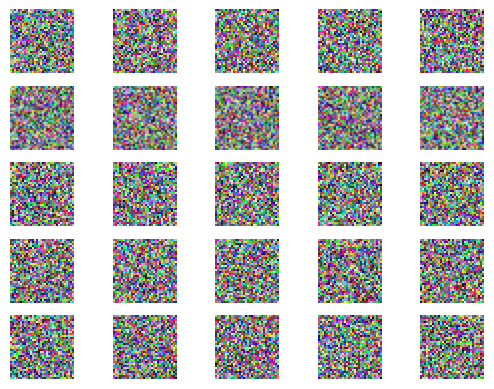

In [ ]:
# plot 25 images
# Temporarily load data to allow plotting; this will load CIFAR10 data based on the current implementation of load_real_samples.
# The load_real_samples function (in cell 8U731mO0vHFE) needs to be updated to load your custom dataset.
if 'load_real_samples' in globals():
    X_images, _ = load_real_samples()
else:
    print("Error: load_real_samples function not defined. Please ensure relevant cells are executed.")
    # Fallback for demonstration if load_real_samples isn't defined yet
    import numpy as np
    X_images = np.random.rand(25, 32, 32, 3) # Dummy data for visualization

for i in range(25):
    plt.subplot(5, 5, 1 + i)
    plt.axis('off')
    plt.imshow(X_images[i])
plt.show()

In [ ]:
# #############################################################################
# #Define generator, discriminator, gan and other helper functions
# #We will use functional way of defining model as we have multiple inputs;
# #both images and corresponding labels.
# ########################################################################

# # define the standalone discriminator model
# #Given an input image, the Discriminator outputs the likelihood of the image being real.
# #Binary classification - true or false (1 or 0). So using sigmoid activation.

# #Unlike regular GAN here we are also providing number of classes as input.
# #Input to the model will be both images and labels.
def define_discriminator(in_shape=(32,32,3), n_classes=2):

    # label input
	in_label = Input(shape=(1,))  #Shape 1
	# embedding for categorical input
    #each label (total 10 classes for cifar), will be represented by a vector of size 50.
    #This vector of size 50 will be learnt by the discriminator
	li = Embedding(n_classes, 50)(in_label) #Shape 1,50
	# scale up to image dimensions with linear activation
	n_nodes = in_shape[0] * in_shape[1]  #32x32 = 1024.
	li = Dense(n_nodes)(li)  #Shape = 1, 1024
	# reshape to additional channel
	li = Reshape((in_shape[0], in_shape[1], 1))(li)  #32x32x1


	# image input
	in_image = Input(shape=in_shape) #32x32x3
	# concat label as a channel
	merge = Concatenate()([in_image, li]) #32x32x4 (4 channels, 3 for image and the other for labels)

	# downsample: This part is same as unconditional GAN upto the output layer.
    #We will combine input label with input image and supply as inputs to the model.
	fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(merge) #16x16x128
	fe = LeakyReLU(negative_slope=0.2)(fe)
	# downsample
	fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(fe) #8x8x128
	fe = LeakyReLU(negative_slope=0.2)(fe)
	# flatten feature maps
	fe = Flatten()(fe)  #8192  (8*8*128=8192)
	# dropout
	fe = Dropout(0.4)(fe)
	# output
	out_layer = Dense(1, activation='sigmoid')(fe)  #Shape=1

	# define model
    ##Combine input label with input image and supply as inputs to the model.
	model = Model([in_image, in_label], out_layer)
	# compile model
	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
	return model

test_discr = define_discriminator()
print(test_discr.summary())


# # define the standalone generator model
# #latent vector and label as inputs


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1, 50)     │        100 │ input_layer_14[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1, 1024)   │     52,224 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 32, 32, 1) │          0 │ dense_14[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 32, 32, 4) │          0 │ input_layer_15[0… │
│ (Concatenate)       │                   │            │ reshape_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │      4,736 │ concatenate_7[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_17      │ (None, 16, 16,    │          0 │ conv2d_11[0][0]   │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 8, 8, 128) │    147,584 │ leaky_re_lu_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_18      │ (None, 8, 8, 128) │          0 │ conv2d_12[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 8192)      │          0 │ leaky_re_lu_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 8192)      │          0 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │      8,193 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 212,837 (831.39 KB)

 Trainable params: 212,837 (831.39 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
def define_generator(latent_dim, n_classes=2):

	# label input
	in_label = Input(shape=(1,))  #Input of dimension 1
	# embedding for categorical input
    #each label (total 10 classes for cifar), will be represented by a vector of size 50.
	li = Embedding(n_classes, 50)(in_label) #Shape 1,50

	# linear multiplication
	n_nodes = 8 * 8  # To match the dimensions for concatenation later in this step.
	li = Dense(n_nodes)(li) #1,64
	# reshape to additional channel
	li = Reshape((8, 8, 1))(li)


	# image generator input
	in_lat = Input(shape=(latent_dim,))  #Input of dimension 100

	# foundation for 8x8 image
    # We will reshape input latent vector into 8x8 image as a starting point.
    #So n_nodes for the Dense layer can be 128x8x8 so when we reshape the output
    #it would be 8x8x128 and that can be slowly upscaled to 32x32 image for output.
    #Note that this part is same as unconditional GAN until the output layer.
    #While defining model inputs we will combine input label and the latent input.
	n_nodes = 128 * 8 * 8
	gen = Dense(n_nodes)(in_lat)  #shape=8192
	gen = LeakyReLU(negative_slope=0.2)(gen)
	gen = Reshape((8, 8, 128))(gen) #Shape=8x8x128
	# merge image gen and label input
	merge = Concatenate()([gen, li])  #Shape=8x8x129 (Extra channel corresponds to the label)
	# upsample to 16x16
	gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(merge) #16x16x128
	gen = LeakyReLU(negative_slope=0.2)(gen)
	# upsample to 32x32
	gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(gen) #32x32x128
	gen = LeakyReLU(negative_slope=0.2)(gen)
	# output
	out_layer = Conv2D(3, (8,8), activation='tanh', padding='same')(gen) #32x32x3
	# define model
	model = Model([in_lat, in_label], out_layer)
	return model   #Model not compiled as it is not directly trained like the discriminator.

test_gen = define_generator(100, n_classes=2)
print(test_gen.summary())


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_16      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 8192)      │    827,392 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 50)     │        100 │ input_layer_16[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_19      │ (None, 8192)      │          0 │ dense_17[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1, 64)     │      3,264 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_12          │ (None, 8, 8, 128) │          0 │ leaky_re_lu_19[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_11          │ (None, 8, 8, 1)   │          0 │ dense_16[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 8, 8, 129) │          0 │ reshape_12[0][0], │
│ (Concatenate)       │                   │            │ reshape_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 16, 16,    │    264,320 │ concatenate_8[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_20      │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 32, 32,    │    262,272 │ leaky_re_lu_20[0… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_21      │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32, 3) │     24,579 │ leaky_re_lu_21[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,381,927 (5.27 MB)

 Trainable params: 1,381,927 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# #Generator is trained via GAN combined model.
# # define the combined generator and discriminator model, for updating the generator
# #Discriminator is trained separately so here only generator will be trained by keeping
# #the discriminator constant.
def define_gan(g_model, d_model):
	d_model.trainable = False  #Discriminator is trained separately. So set to not trainable.

    ## connect generator and discriminator...
	# first, get noise and label inputs from generator model
	gen_noise, gen_label = g_model.input  #Latent vector size and label size
	# get image output from the generator model
	gen_output = g_model.output  #32x32x3

	# generator image output and corresponding input label are inputs to discriminator
	gan_output = d_model([gen_output, gen_label])
	# define gan model as taking noise and label and outputting a classification
	model = Model([gen_noise, gen_label], gan_output)
	# compile model
	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt)
	return model

In [23]:
import os
from PIL import Image
import numpy as np

# load images and their corresponding labels from the custom dataset
def load_real_samples():
    # Define paths to image and label directories
    image_dir = '/content/unzipped_archive/png/train/'
    label_dir = '/content/unzipped_archive/png/train_labels/'

    all_images = []
    all_labels = []

    # Get a list of all image files
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])

    for img_file in image_files:
        # Load image
        img_path = os.path.join(image_dir, img_file)
        img = Image.open(img_path).convert('RGB')
        img = np.asarray(img).astype('float32')
        all_images.append(img)

        # Load corresponding label mask
        # Assuming label filenames match image filenames (e.g., 22678915_15.png and 22678915_15.png)
        label_path = os.path.join(label_dir, img_file) # Adjusted to match png/train_labels structure
        label = Image.open(label_path).convert('L') # Convert to grayscale for single channel
        label = np.asarray(label)

        # Convert label mask to binary (0 for background, 1 for building)
        # Based on label_class_dict.csv: background (0,0,0), building (255,255,255)
        # So, pixels with value 255 are 'building' (label 1), others are 'background' (label 0)
        binary_label = (label == 255).astype(int)

        # If the GAN expects a single class label per image, we need to decide how to represent it.
        # For segmentation, we usually feed the mask. For conditional GAN, we usually feed a single class.
        # Given the original GAN was for CIFAR10 where each image had one class, let's simplify for now:
        # if 'building' pixels exist, classify as 'building' (1), otherwise 'background' (0).
        # This is a simplification; for full segmentation, the approach would be different.
        if np.any(binary_label == 1):
            all_labels.append(1) # Building present
        else:
            all_labels.append(0) # Only background


    # Convert lists to numpy arrays
    X = np.asarray(all_images)
    trainy = np.asarray(all_labels)
    trainy = trainy.reshape(-1, 1)

    # Normalize images from [0,255] to [-1,1] (matching generator tanh output)
    X = (X - 127.5) / 127.5

    print(f"Loaded {len(all_images)} images and labels.")
    print(f"Image shape: {X.shape}")
    print(f"Label shape: {trainy.shape}")

    return [X, trainy]





# # select real samples
# pick a batch of random real samples to train the GAN
#In fact, we will train the GAN on a half batch of real images and another
#half batch of fake images.
#For each real image we assign a label 1 and for fake we assign label 0.
def generate_real_samples(dataset, n_samples):
	# split into images and labels
	images, labels = dataset
	# choose random instances
	ix = randint(0, images.shape[0], n_samples)
	# select images and labels
	X, labels = images[ix], labels[ix]
	# generate class labels and assign to y (don't confuse this with the above labels that correspond to cifar labels)
	y = ones((n_samples, 1))  #Label=1 indicating they are real
	return [X, labels], y

# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples, n_classes=2):
	# generate points in the latent space
	x_input = randn(latent_dim * n_samples)
	# reshape into a batch of inputs for the network
	z_input = x_input.reshape(n_samples, latent_dim)
	# generate labels
	labels = randint(0, n_classes, n_samples)
	return [z_input, labels]

# use the generator to generate n fake examples, with class labels
#Supply the generator, latent_dim and number of samples as input.
#Use the above latent point generator to generate latent points.
def generate_fake_samples(generator, latent_dim, n_samples):
	# generate points in latent space
	z_input, labels_input = generate_latent_points(latent_dim, n_samples)
	# predict outputs
	images = generator.predict([z_input, labels_input])
	# create class labels
	y = zeros((n_samples, 1))  #Label=0 indicating they are fake
	return [images, labels_input], y

In [ ]:
# train the generator and discriminator
#We loop through a number of epochs to train our Discriminator by first selecting
#a random batch of images from our true/real dataset.
#Then, generating a set of images using the generator.
#Feed both set of images into the Discriminator.
#Finally, set the loss parameters for both the real and fake images, as well as the combined loss.
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=100, n_batch=128):
	bat_per_epo = int(dataset[0].shape[0] / n_batch)
	half_batch = int(n_batch / 2)  #the discriminator model is updated for a half batch of real samples
                            #and a half batch of fake samples, combined a single batch.
	# manually enumerate epochs
	for i in range(n_epochs):
		# enumerate batches over the training set
		for j in range(bat_per_epo):

             # Train the discriminator on real and fake images, separately (half batch each)
        #Research showed that separate training is more effective.
			# get randomly selected 'real' samples
            # get randomly selected 'real' samples
			[X_real, labels_real], y_real = generate_real_samples(dataset, half_batch)

            # update discriminator model weights
            ##train_on_batch allows you to update weights based on a collection
            #of samples you provide
			d_loss_real, _ = d_model.train_on_batch([X_real, labels_real], y_real)

			# generate 'fake' examples
			[X_fake, labels], y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
			# update discriminator model weights
			d_loss_fake, _ = d_model.train_on_batch([X_fake, labels], y_fake)

            #d_loss = 0.5 * np.add(d_loss_real, d_loss_fake) #Average loss if you want to report single..

			# prepare points in latent space as input for the generator
			[z_input, labels_input] = generate_latent_points(latent_dim, n_batch)

            # The generator wants the discriminator to label the generated samples
        # as valid (ones)
        #This is where the generator is trying to trick discriminator into believing
        #the generated image is true (hence value of 1 for y)
			# create inverted labels for the fake samples
			y_gan = ones((n_batch, 1))
             # Generator is part of combined model where it got directly linked with the discriminator
        # Train the generator with latent_dim as x and 1 as y.
        # Again, 1 as the output as it is adversarial and if generator did a great
        #job of folling the discriminator then the output would be 1 (true)
			# update the generator via the discriminator's error
			g_loss = gan_model.train_on_batch([z_input, labels_input], y_gan)
			# Print losses on this batch
			print('Epoch>%d, Batch%d/%d, d1=%.3f, d2=%.3f g=%.3f' %
				(i+1, j+1, bat_per_epo, d_loss_real, d_loss_fake, g_loss))
	# save the generator model
	g_model.save('cifar_conditional_generator_25epochs.h5')

In [ ]:
#Train the GAN

# size of the latent space
latent_dim = 100
# create the discriminator
d_model = define_discriminator()
# create the generator
g_model = define_generator(latent_dim)
# create the gan
gan_model = define_gan(g_model, d_model)
# load image data
dataset = load_real_samples()
# train model
train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2885s 17us/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Epoch>1, Batch1/390, d1=0.681, d2=0.687 g=0.694
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Epoch>1, Batch2/390, d1=0.686, d2=0.689 g=0.692
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Epoch>1, Batch3/390, d1=0.687, d2=0.689 g=0.690
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Epoch>1, Batch4/390, d1=0.689, d2=0.691 g=0.687
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Epoch>1, Batch5/390, d1=0.690, d2=0.693 g=0.684
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Epoch>1, Batch6/390, d1=0.693, d2=0.696 g=0.680
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Epoch>1, Batch7/390, d1=0.694, d2=0.697 g=0.675
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch>1, Batch8/390, d1=0.696, d2=0.700 g=0.669
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epoch>1, Batch9/390, d1=0.699, d2=0.704 g=0.663
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch>1, Batch10/390, d1=0.703, d2=0.709 g=0.655
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch>1, Batch11/390, d1=0.707, d2=0.714 g=0.646
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch>1, Batch

Epoch>1, Batch390/390, d1=1.331, d2=1.332 g=0.173


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step


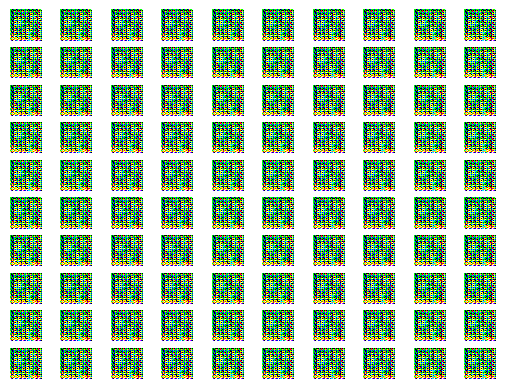

In [ ]:
# Now, let us load the generator model and generate images
# Lod the trained model and generate a few images
from numpy import asarray
from numpy.random import randn
from numpy.random import randint
from keras.models import load_model
import numpy as np
#

#Note: CIFAR10 classes are: airplane, automobile, bird, cat, deer, dog, frog, horse,
# ship, truck

# load model
model = load_model('/content/cifar_conditional_generator_25epochs.h5')

# generate multiple images

latent_points, labels = generate_latent_points(100, 100)
# specify labels - generate 10 sets of labels each gping from 0 to 9
labels = asarray([x for _ in range(10) for x in range(10)])
# generate images
X  = model.predict([latent_points, labels])
# scale from [-1,1] to [0,1]
X = (X + 1) / 2.0
X = (X*255).astype(np.uint8)
# plot the result (10 sets of images, all images in a column should be of same class in the plot)
# Plot generated images
def show_plot(examples, n):
	for i in range(n * n):
		plt.subplot(n, n, 1 + i)
		plt.axis('off')
		plt.imshow(examples[i, :, :, :])
	plt.show()

show_plot(X, 10)

### Accessing Google Drive and Unzipping Files

To access files stored in your Google Drive, you need to mount it. After mounting, we can unzip your `archive (2).zip` file and inspect its contents.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now that your Google Drive is mounted, let's unzip the `archive (2).zip` file. We'll unzip it into a new directory called `unzipped_archive`.

In [ ]:
# Create a directory to extract the contents
!mkdir -p /content/unzipped_archive

# Unzip the file
!unzip -q "/content/drive/MyDrive/archive (2).zip" -d /content/unzipped_archive

print("File unzipped successfully to /content/unzipped_archive")

File unzipped successfully to /content/unzipped_archive


Let's list the contents of the unzipped directory to see what files are available.

In [ ]:
# List the contents of the unzipped directory
!ls -F /content/unzipped_archive/

label_class_dict.csv  metadata.csv  png/  tiff/


### Inspecting `metadata.csv`

Let's load the `metadata.csv` file into a pandas DataFrame and display its head to get an overview of the data.

In [ ]:
import pandas as pd

metadata_path = '/content/unzipped_archive/metadata.csv'
metadata_df = pd.read_csv(metadata_path)

print("First 5 rows of metadata.csv:")
print(metadata_df.head())

First 5 rows of metadata.csv:
      image_id  split                                    image_souce_url  \
0  22678915_15  train  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   
1  22678930_15  train  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   
2  22678945_15  train  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   
3  22678960_15  train  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   
4  22678975_15  train  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   

                                    label_source_url  \
0  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   
1  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   
2  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   
3  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   
4  http://www.cs.toronto.edu/~vmnih/data/mass_bui...   

               tiff_image_path                     tif_label_path  \
0  tiff/train/22678915_15.tiff  tiff/train_labels/22678915_15.tif   
1  tiff/train/22678930_15.tiff  tiff/t

### Inspecting `label_class_dict.csv`

Let's load the `label_class_dict.csv` file to understand the mapping of numerical labels to class names for this dataset.

In [ ]:
label_class_path = '/content/unzipped_archive/label_class_dict.csv'
label_class_df = pd.read_csv(label_class_path)

print("Contents of label_class_dict.csv:")
print(label_class_df.head())


Contents of label_class_dict.csv:
         name    r    g    b
0  background    0    0    0
1    building  255  255  255
